# LAB7
### Dewang Choudhary            
### BL.EN.U4AIE23145

Selected audio: c:\DewangData\Learning\SpeechProcessing\LJ001-0003.wav
Sampling rate: 22050 Hz, duration: 9.67 s


Chosen frame index: 24
Frame start time: 0.239 s
Cepstral peak quefrency: 6.44 ms
Estimated fundamental frequency (F0): 155.28 Hz


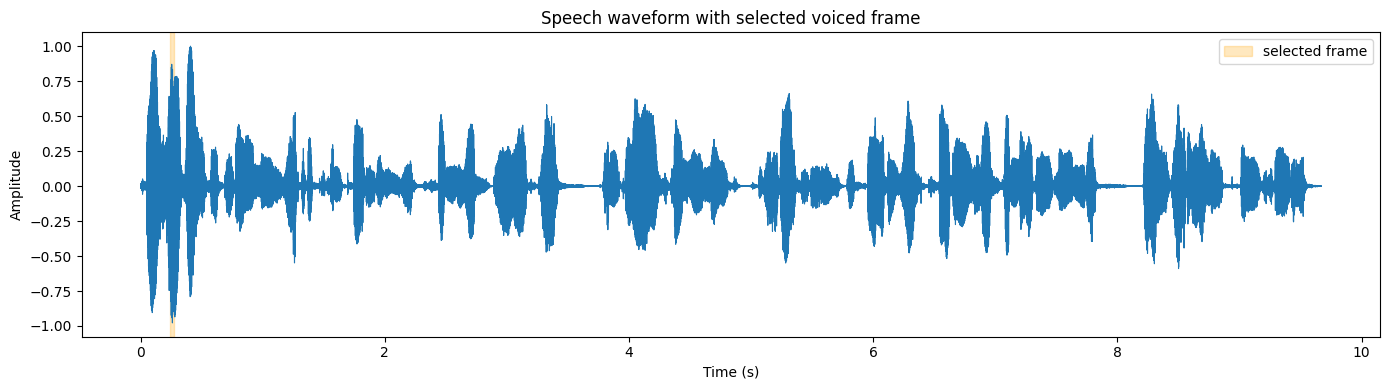

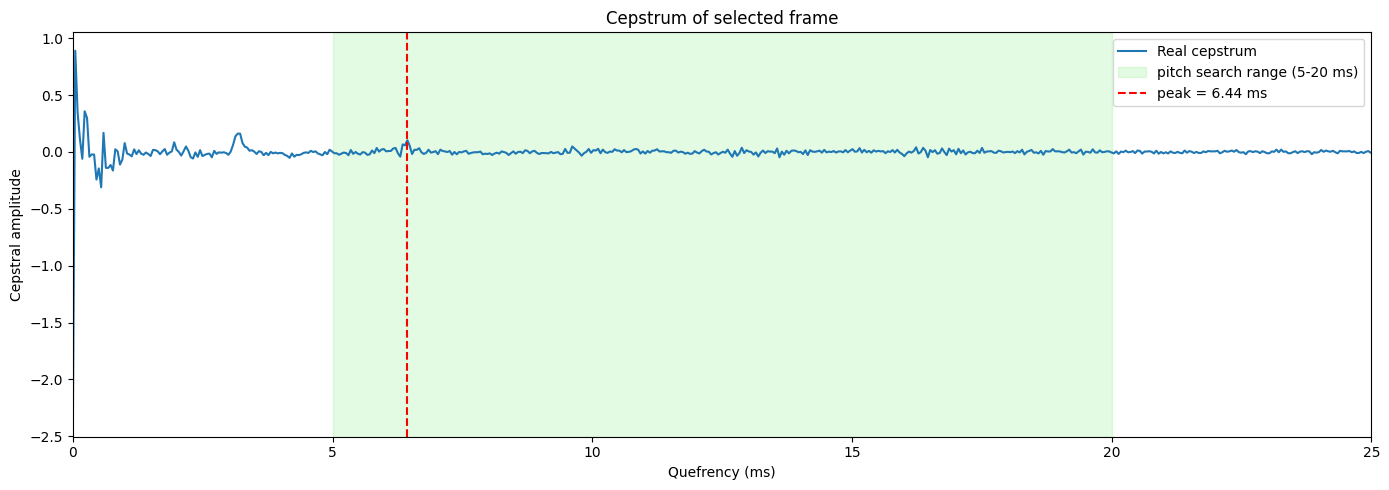

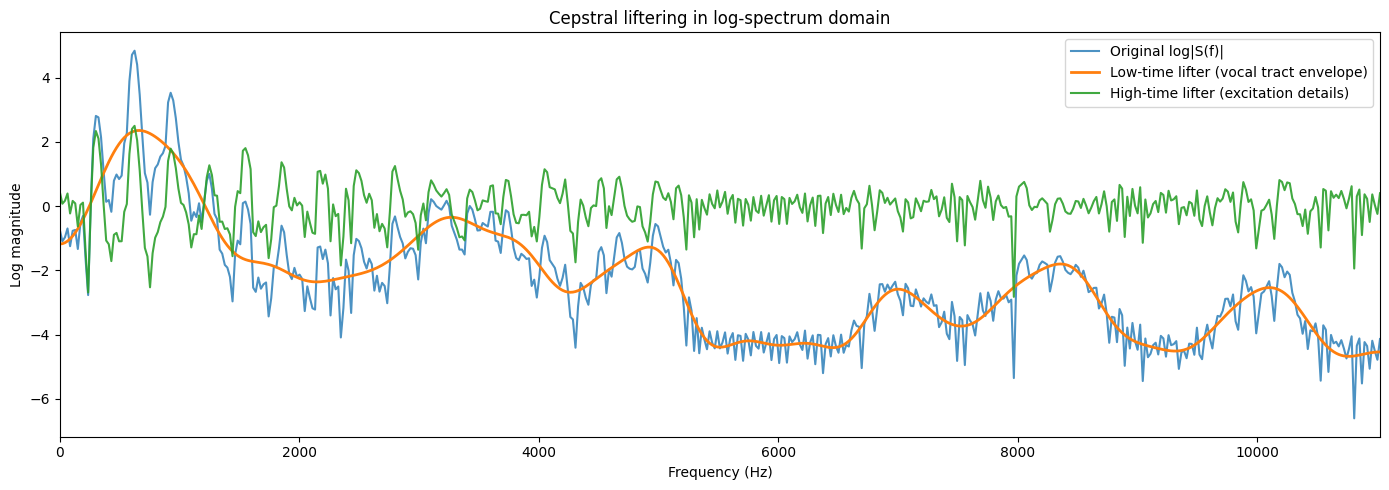

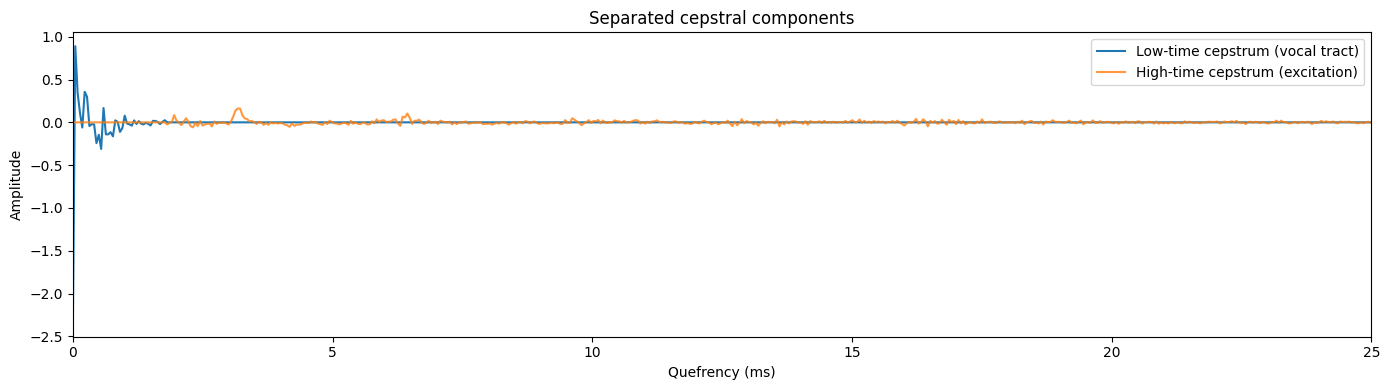


Detailed inference:
1. Real cepstrum was computed on a voiced frame selected using a high-energy and low-ZCR heuristic.
2. In the cepstrum, a distinct peak appears in the pitch region (5-20 ms), which corresponds to periodic vocal-fold excitation.
3. Estimated pitch period T0 = 6.44 ms, giving F0 = 155.28 Hz.
4. Low-time liftering keeps slowly varying cepstral terms and reconstructs a smooth spectral envelope, which models vocal tract resonances.
5. High-time liftering keeps rapid variations and periodic fine structure, emphasizing source and excitation information.
6. The separation confirms source-filter speech production: excitation periodicity appears as a cepstral peak, while vocal-tract characteristics dominate the smooth envelope.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.io import wavfile
from scipy.signal import get_window, find_peaks
from IPython.display import Audio, display

audio_path = Path.cwd().parent / "LJ001-0003.wav"
if not audio_path.exists():
    audio_path = Path(r"c:\DewangData\Learning\SpeechProcessing\LJ001-0003.wav")
if not audio_path.exists():
    raise FileNotFoundError("LJ001-0003.wav not found.")

fs, x = wavfile.read(audio_path)
if x.ndim > 1:
    x = x.mean(axis=1)

x = x.astype(np.float64)
mx = np.max(np.abs(x))
if mx > 0:
    x = x / mx

print(f"Selected audio: {audio_path}")
print(f"Sampling rate: {fs} Hz, duration: {len(x) / fs:.2f} s")
display(Audio(x, rate=fs))

frame_dur = 0.03
hop_dur = 0.01
N = int(frame_dur * fs)
H = int(hop_dur * fs)
win = get_window("hamming", N, fftbins=True)

frames = np.array([x[i:i + N] * win for i in range(0, len(x) - N, H)])
if len(frames) == 0:
    raise ValueError("Audio too short for frame-based analysis.")

energies = np.sum(frames ** 2, axis=1)
zcr = np.mean(np.abs(np.diff(np.sign(frames), axis=1)) > 0, axis=1)
energy_n = energies / (np.max(energies) + 1e-12)
zcr_n = zcr / (np.max(zcr) + 1e-12)
voiced_score = energy_n - 0.35 * zcr_n
best_idx = int(np.argmax(voiced_score))

frame = frames[best_idx]
start_sample = best_idx * H
time_axis = np.arange(len(x)) / fs

def real_cepstrum(sig, nfft=None):
    if nfft is None:
        nfft = int(2 ** np.ceil(np.log2(len(sig))))
    S = np.fft.rfft(sig, n=nfft)
    log_mag = np.log(np.abs(S) + 1e-10)
    c = np.fft.irfft(log_mag, n=nfft)
    return c, log_mag, nfft

cep, log_mag, nfft = real_cepstrum(frame)
q = np.arange(len(cep)) / fs

q_min, q_max = 0.005, 0.020
k_min, k_max = int(q_min * fs), int(q_max * fs)
search_region = cep[k_min:k_max]
if len(search_region) == 0:
    raise ValueError("Pitch search region is empty.")

peaks, _ = find_peaks(search_region)
if len(peaks) > 0:
    peak_local = peaks[np.argmax(search_region[peaks])]
    k0 = k_min + peak_local
else:
    k0 = k_min + int(np.argmax(search_region))

pitch_period = k0 / fs
f0 = 1.0 / pitch_period if pitch_period > 0 else np.nan

print(f"Chosen frame index: {best_idx}")
print(f"Frame start time: {start_sample / fs:.3f} s")
print(f"Cepstral peak quefrency: {pitch_period * 1000:.2f} ms")
print(f"Estimated fundamental frequency (F0): {f0:.2f} Hz")

L = min(40, len(cep))
low_cep = np.zeros_like(cep)
low_cep[:L] = cep[:L]
if L > 1:
    low_cep[-(L - 1):] = cep[-(L - 1):]
high_cep = cep - low_cep
vocal_tract_log_spec = np.real(np.fft.rfft(low_cep, n=nfft))
excitation_log_spec = np.real(np.fft.rfft(high_cep, n=nfft))
freq_axis = np.fft.rfftfreq(nfft, d=1 / fs)

plt.figure(figsize=(14, 4))
plt.plot(time_axis, x, lw=0.8)
plt.axvspan(start_sample / fs, (start_sample + N) / fs, color="orange", alpha=0.25, label="selected frame")
plt.title("Speech waveform with selected voiced frame")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(q * 1000, cep, label="Real cepstrum")
plt.axvspan(q_min * 1000, q_max * 1000, color="lightgreen", alpha=0.25, label="pitch search range (5-20 ms)")
plt.axvline(pitch_period * 1000, color="r", ls="--", label=f"peak = {pitch_period * 1000:.2f} ms")
plt.xlim(0, 25)
plt.title("Cepstrum of selected frame")
plt.xlabel("Quefrency (ms)")
plt.ylabel("Cepstral amplitude")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(freq_axis, log_mag, label="Original log|S(f)|", alpha=0.8)
plt.plot(freq_axis, vocal_tract_log_spec, label="Low-time lifter (vocal tract envelope)", lw=2)
plt.plot(freq_axis, excitation_log_spec, label="High-time lifter (excitation details)", alpha=0.9)
plt.title("Cepstral liftering in log-spectrum domain")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Log magnitude")
plt.xlim(0, fs / 2)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(q * 1000, low_cep, label="Low-time cepstrum (vocal tract)")
plt.plot(q * 1000, high_cep, label="High-time cepstrum (excitation)", alpha=0.8)
plt.xlim(0, 25)
plt.title("Separated cepstral components")
plt.xlabel("Quefrency (ms)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

inference = f"""
Detailed inference:
1. Real cepstrum was computed on a voiced frame selected using a high-energy and low-ZCR heuristic.
2. In the cepstrum, a distinct peak appears in the pitch region (5-20 ms), which corresponds to periodic vocal-fold excitation.
3. Estimated pitch period T0 = {pitch_period * 1000:.2f} ms, giving F0 = {f0:.2f} Hz.
4. Low-time liftering keeps slowly varying cepstral terms and reconstructs a smooth spectral envelope, which models vocal tract resonances.
5. High-time liftering keeps rapid variations and periodic fine structure, emphasizing source and excitation information.
6. The separation confirms source-filter speech production: excitation periodicity appears as a cepstral peak, while vocal-tract characteristics dominate the smooth envelope.
"""
print(inference)